In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# data = pd.read_table('b1.txt', names=['x','d1','d2','d3','d4','d5','d6'])
# data['t'] = data.index * 1e-5
# data[['t','x']].to_csv('data.txt', index=None)

In [87]:
data = pd.read_table('data.txt', sep=",")
data_downsampled = data[::100]
# data_downsampled.to_csv('data_downsampled.csv', index=None)

<Axes: xlabel='t'>

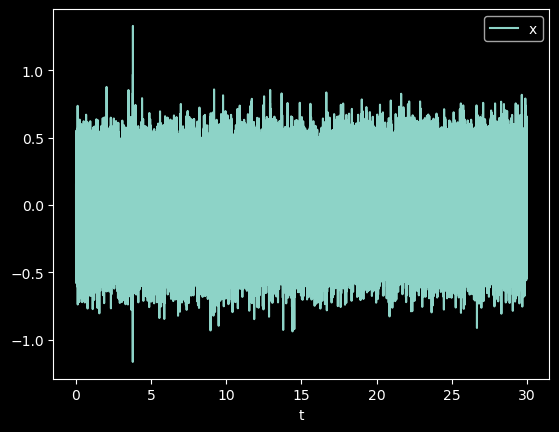

In [88]:
data.plot(x='t', y='x')

<ErrorbarContainer object of 3 artists>

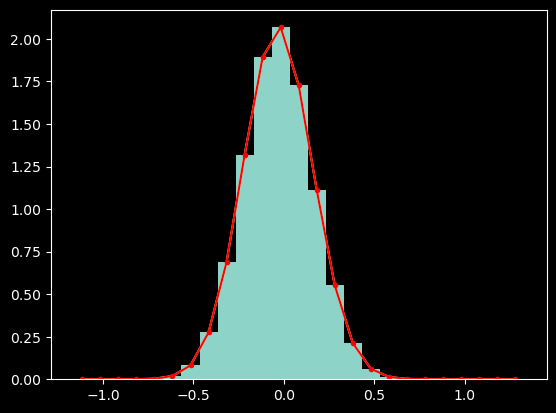

In [184]:
heights, bins, _ = plt.hist(data['x'], bins=25, density=True)

dx = bins[1]-bins[0]
N = len(data)

raw_counts, raw_bins = np.histogram(data['x'], bins=25, density=False)

heights_err = np.sqrt(raw_counts)/N

bins = bins[:-1]+dx/2
plt.plot(bins, heights)
plt.errorbar(bins, heights, yerr=heights_err, marker='.', color='r')

[26.82329253 -0.03128848]
[0.34527848 0.0017736 ]


<ErrorbarContainer object of 3 artists>

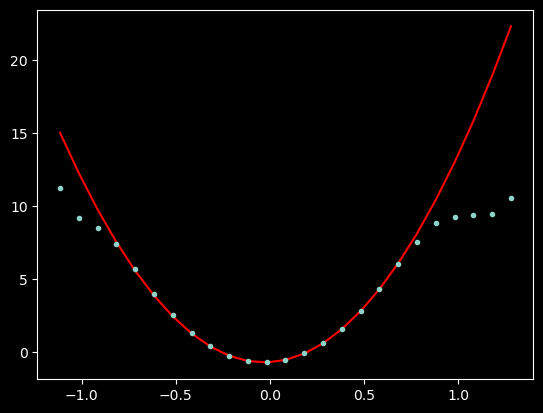

In [189]:
U_err = 2*heights_err/heights
popt, pcov = scipy.optimize.curve_fit(lambda x, k, x_0: 0.5*k*(x-x_0)**2-0.5*np.log(k/(2*np.pi)), xdata=bins, ydata=-np.log(heights), p0=[8, 0.5], sigma=U_err)
plt.plot(bins, 0.5*popt[0]*(bins-popt[1])**2-0.5*np.log(popt[0]/(2*np.pi)), 'r')
print(popt)
print(np.sqrt(np.diag(pcov)))

plt.errorbar(bins, -np.log(heights), yerr=U_err, lw=0, marker='.')

In [97]:
1/np.std(data['x'])**2

27.653471009791787

In [ ]:
df = pd.DataFrame(np.array([bins, heights, np.where(heights != 0, -np.log(heights), np.nan), U_err])).T.rename(columns={0: 'x', 1: 'p', 2: 'E', 3:'dE'})
df.to_csv('gaussian_data.csv', index=None)

In [141]:
len(data['x'])

3000000

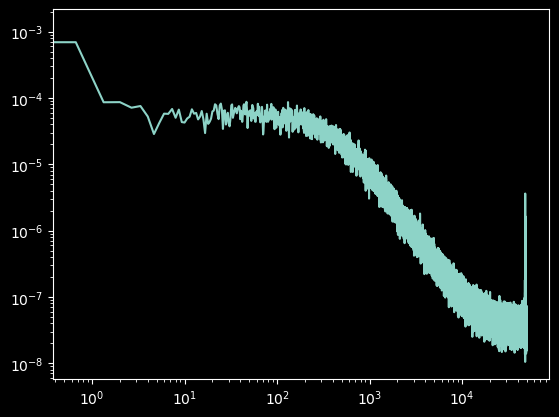

In [142]:
S_f, S = scipy.signal.welch(data['x'], fs=10**5, noverlap=0, nperseg=round((len(data['x'])-1)/20/2)*2, detrend=False)
plt.loglog(S_f, S)

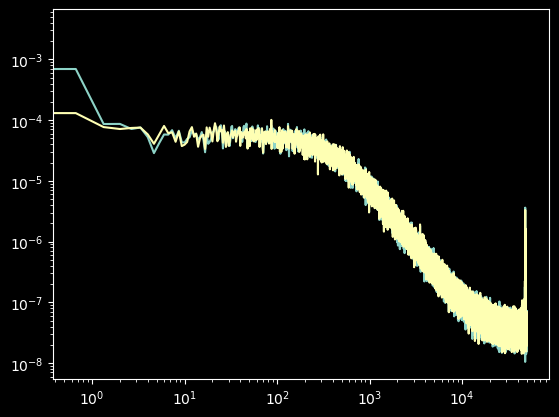

In [145]:
PS_f, PS = np.genfromtxt('PS_x1.txt', skip_header=1, delimiter=",").T

plt.loglog(S_f, S)
plt.loglog(PS_f, PS)